In [1]:
import re
import math
import pandas as pd
import ast


In [2]:
import re
import math

def extract_tensor_values(sparsities_str):
    tensor_strings = sparsities_str.strip('()').split('), ')
    values = []
    for tensor_str in tensor_strings:
        match = re.search(r"tensor\(([\d.]+)", tensor_str)
        if match:
            values.append(float(match.group(1)))
    return values

# def get_linear_bops(in_features, out_features, sparsity, bit_width):
#     effective_connections = in_features * out_features * (1 - sparsity)
#     mult_bops = effective_connections * bit_width * bit_width
#     add_bops = effective_connections * (2 * bit_width + math.ceil(math.log2(in_features)))
#     return mult_bops + add_bops

def get_linear_bops(in_features, out_features, sparsity, bit_width=32):
    return out_features * in_features * (1 - sparsity) * (
         bit_width**2 + 2*bit_width + math.log2(in_features)
        
    )

def calculate_model_bops(model_name, phi_sparsities, rho_sparsities, bit_width):
    model_architectures = {
        'Large': {
            'phi': [(3, 32), (32, 32)],
            'rho': [(32, 32), (32, 64), (64, 5)]
        },
        'Medium': {
            'phi': [(3, 32), (32, 16)],
            'rho': [(16, 64), (64, 8), (8, 32), (32, 5)]
        },
        'Small': {
            'phi': [(3, 8), (8, 8)],
            'rho': [(8, 16), (16, 16), (16, 5)]
        },
        'Tiny': {
            'phi': [(3, 16)],
            'rho': [(16, 8), (8, 8), (8, 4), (4, 5)]
        }
    }

    #Deepsets original architecture
    Deepsets = {
        'phi': [(3, 32), (32, 32), (32, 32)],
        'rho': [(32, 16), (16, 5)]
    }


    architecture = model_architectures[model_name]
    total_bops = 0

    for (in_features, out_features), sparsity in zip(architecture['phi'], phi_sparsities):
        total_bops += get_linear_bops(in_features, out_features, sparsity, bit_width)*8

    for (in_features, out_features), sparsity in zip(architecture['rho'], rho_sparsities):
        total_bops += get_linear_bops(in_features, out_features, sparsity, bit_width)

    return total_bops


def calculate_original_deepsets_bops(bit_width=32):
    Deepsets = {
        'phi': [(3, 32), (32, 32), (32, 32)],
        'rho': [(32, 16), (16, 5)]
    }
    
    total_bops = 0
    
    for in_features, out_features in Deepsets['phi']:
        total_bops += get_linear_bops(in_features, out_features, sparsity=0, bit_width=bit_width)*8
    
    for in_features, out_features in Deepsets['rho']:
        total_bops += get_linear_bops(in_features, out_features, sparsity=0, bit_width=bit_width)
    
    return total_bops

# Calculate BOPs for the original Deepsets model
original_deepsets_bops = calculate_original_deepsets_bops(8)
print(f"Original Deepsets BOPs: {original_deepsets_bops:.2e}")


def extract_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    data = {}
    for line in lines:
        match = re.match(r"Deepsets (\w+) Model (\d+)-Bit QAT Model Prune Iter: (\d+)", line)
        if match:
            model_name, bit_width, iteration = match.groups()
            full_model_name = f"Deepsets {model_name} Model {bit_width}-Bit QAT Model"
            
            if full_model_name not in data:
                data[full_model_name] = {
                    'model_name': [],
                    'bit_width': [],
                    'iteration': [],
                    'test_accuracy': [],
                    'val_accuracy': [],
                    'val_loss': [],
                    'phi_sparsities': [],
                    'rho_sparsities': [],
                    'total_bops': [],
                    'net sparsity': []
                }
            
            test_accuracy = float(re.search(r"Test Accuracy: ([\d.]+)", line).group(1))
            val_accuracy = float(re.search(r"Val Accuracy: ([\d.]+)", line).group(1))
            val_loss = float(re.search(r"Val Loss: ([\d.]+)", line).group(1))
            
            phi_sparsities_str = re.search(r"Phi Sparsities: (.*?) Rho Sparsities:", line).group(1)
            rho_sparsities_str = re.search(r"Rho Sparsities: (.*?)$", line).group(1)

            phi_sparsities = extract_tensor_values(phi_sparsities_str)
            rho_sparsities = extract_tensor_values(rho_sparsities_str)

            # Calculate BOPs
            total_bops = calculate_model_bops(model_name, phi_sparsities, rho_sparsities, int(bit_width))

            net_sparsity = 1- 0.8**int(iteration)

            # Append data to the respective lists
            data[full_model_name]['model_name'].append(model_name)
            data[full_model_name]['bit_width'].append(int(bit_width))
            data[full_model_name]['iteration'].append(int(iteration))
            data[full_model_name]['test_accuracy'].append(test_accuracy)
            data[full_model_name]['val_accuracy'].append(val_accuracy)
            data[full_model_name]['val_loss'].append(val_loss)
            data[full_model_name]['phi_sparsities'].append(phi_sparsities)
            data[full_model_name]['rho_sparsities'].append(rho_sparsities)
            data[full_model_name]['total_bops'].append(total_bops)

            data[full_model_name]['net sparsity'].append(net_sparsity)
            # print("phi_sparsities:", phi_sparsities, "rho_sparsities:", rho_sparsities)

            # print(f"model name: {model_name}, total_bops: {total_bops:.2e}, net sparsity: {net_sparsity:.4f}, bit width: {bit_width}")

    return data

# file_path = './combined_deepsets_Compress_Aug7.txt'
file_path = './combined_sep18_deepsets_compress.txt'
# file_path = 'localsearch_results_sep16/combined_deepsets_compress.txt'
# file_path = './global_search_results_central/combined.txt'

extracted_data = extract_data(file_path)


print(extracted_data.keys())
print(extracted_data['Deepsets Large Model 8-Bit QAT Model'].keys())





Original Deepsets BOPs: 1.51e+06
dict_keys(['Deepsets Large Model 32-Bit QAT Model', 'Deepsets Large Model 16-Bit QAT Model', 'Deepsets Large Model 8-Bit QAT Model', 'Deepsets Large Model 4-Bit QAT Model', 'Deepsets Medium Model 32-Bit QAT Model', 'Deepsets Medium Model 16-Bit QAT Model', 'Deepsets Medium Model 8-Bit QAT Model', 'Deepsets Medium Model 4-Bit QAT Model', 'Deepsets Small Model 32-Bit QAT Model', 'Deepsets Small Model 16-Bit QAT Model', 'Deepsets Small Model 8-Bit QAT Model', 'Deepsets Small Model 4-Bit QAT Model', 'Deepsets Tiny Model 32-Bit QAT Model', 'Deepsets Tiny Model 16-Bit QAT Model', 'Deepsets Tiny Model 8-Bit QAT Model', 'Deepsets Tiny Model 4-Bit QAT Model'])
dict_keys(['model_name', 'bit_width', 'iteration', 'test_accuracy', 'val_accuracy', 'val_loss', 'phi_sparsities', 'rho_sparsities', 'total_bops', 'net sparsity'])


Plot saved as ./plots/BOPs_vs_Accuracy_sept23_with_opacity.pdf


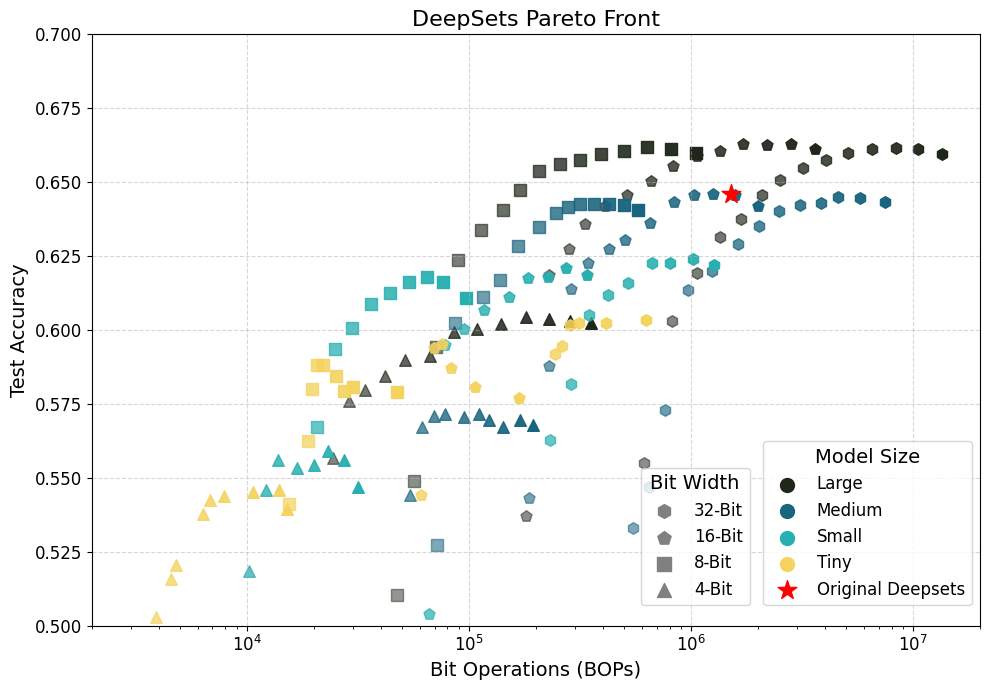

In [3]:
import matplotlib.pyplot as plt
import re

def plot_bops_vs_accuracy(data, output_folder='./plots'):
    plt.figure(figsize=(10, 7))
    
    model_order = ['Tiny', 'Small', 'Medium', 'Large']
    
    color_families = {
        'Tiny': '#F4D35E',
        'Small': '#28AFB0',
        'Medium': '#19647E',
        'Large': '#1F271B'
    }

    bit_width_shapes = {
        4: '^',  # triangle
        8: 's',  # square
        16: 'p',  # pentagon
        32: 'h'   # hexagon
    }

    # Create separate handles for legends
    color_handles = []
    shape_handles = []

    for full_model_name, model_data in data.items():
        match = re.match(r"Deepsets (\w+) Model (\d+)-Bit QAT Model", full_model_name)
        if match:
            model_size, bit_width = match.groups()
            bit_width = int(bit_width)

            if model_size in model_order:
                color = color_families[model_size]
                shape = bit_width_shapes[bit_width]

                # Calculate opacity based on iteration
                max_iteration = max(model_data['iteration'])
                for i, (bops, accuracy, iteration) in enumerate(zip(model_data['total_bops'], model_data['test_accuracy'], model_data['iteration'])):
                    opacity = 1 - 0.7 * (iteration / max_iteration)  # This will range from 1 to 0.6
                    plt.scatter(bops, accuracy, marker=shape, color=color, s=70, alpha=opacity)

                # Add handles for legends (only once per model size and bit width)
                if model_size not in [h.get_label() for h in color_handles]:
                    color_handles.append(plt.scatter([], [], color=color, s=100, label=model_size))
                if bit_width not in [int(h.get_label().split('-')[0]) for h in shape_handles]:
                    shape_handles.append(plt.scatter([], [], marker=shape, color='gray', s=100, label=f'{bit_width}-Bit'))

    # Add the original Deepsets model point
    original_deepsets_bops = calculate_original_deepsets_bops(8)
    plt.scatter(original_deepsets_bops, 0.646, marker='*', color='red', s=200, zorder=5)
    color_handles.append(plt.scatter([], [], marker='*', color='red', s=200, label='Original Deepsets'))

    plt.xscale('log') 
    plt.xlabel('Bit Operations (BOPs)', fontsize=14)
    plt.ylabel('Test Accuracy', fontsize=14)
    plt.title('DeepSets Pareto Front', fontsize=16)
    plt.grid(True, which="major", ls="--", alpha=0.5)
    plt.xlim(2e3, 2e7)
    plt.ylim(0.5, 0.7)

    # Increase tick label font size
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Create two separate legends side by side
    first_legend = plt.legend(handles=color_handles, title='Model Size', loc='lower right', 
                              bbox_to_anchor=(1, 0.02), fontsize=12, title_fontsize=14)
    plt.gca().add_artist(first_legend)  # Add the first legend to the plot
    plt.legend(handles=shape_handles, title='Bit Width', loc='lower right', 
               bbox_to_anchor=(0.75, 0.02), fontsize=12, title_fontsize=14)

    plt.tight_layout()
    plt.savefig(f'{output_folder}/BOPs_vs_Accuracy_sept11_with_opacity.pdf', dpi=300, bbox_inches='tight')
    print(f"Plot saved as {output_folder}/BOPs_vs_Accuracy_sept23_with_opacity.pdf")
    
    plt.show()

extracted_data = extract_data(file_path)
plot_bops_vs_accuracy(extracted_data)

Plot saved as /Users/dimademler/Downloads/BOPs_vs_Accuracy_oct1_with_lines.pdf


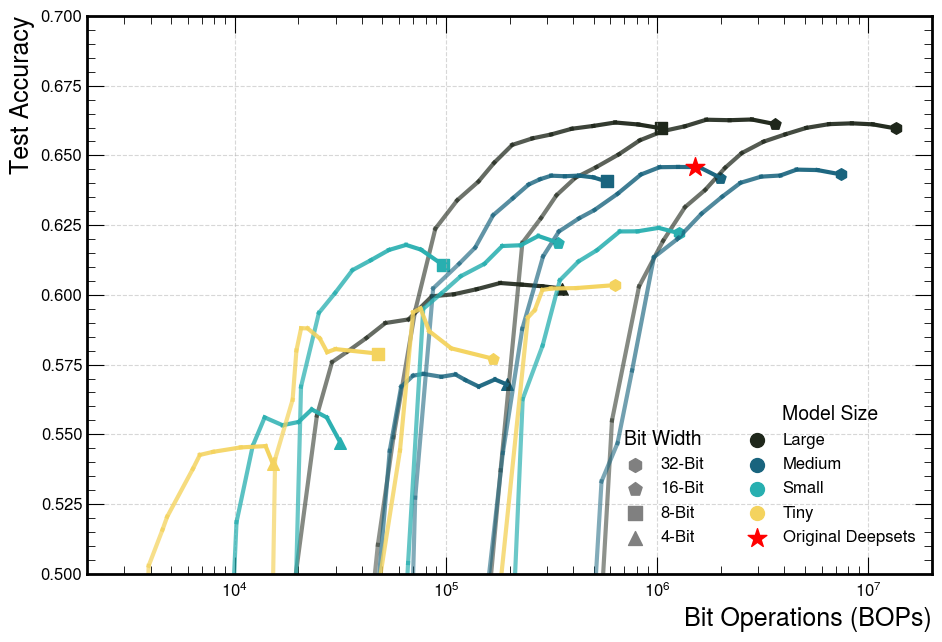

In [4]:
import matplotlib.pyplot as plt
import re
from collections import defaultdict

import mplhep as hep
plt.style.use(hep.style.ROOT)


def plot_bops_vs_accuracy(data, output_folder='./plots'):
    plt.figure(figsize=(10, 7))
    
    model_order = ['Tiny', 'Small', 'Medium', 'Large']
    
    color_families = {
        'Tiny': '#F4D35E',
        'Small': '#28AFB0',
        'Medium': '#19647E',
        'Large': '#1F271B'
    }

    bit_width_shapes = {
        4: '^',  # triangle
        8: 's',  # square
        16: 'p',  # pentagon
        32: 'h'   # hexagon
    }

    # Create separate handles for legends
    color_handles = []
    shape_handles = []

    # Group data by model size and bit width
    grouped_data = defaultdict(lambda: defaultdict(list))

    for full_model_name, model_data in data.items():
        match = re.match(r"Deepsets (\w+) Model (\d+)-Bit QAT Model", full_model_name)
        if match:
            model_size, bit_width = match.groups()
            bit_width = int(bit_width)

            if model_size in model_order:
                for bops, accuracy, iteration in zip(model_data['total_bops'], model_data['test_accuracy'], model_data['iteration']):
                    grouped_data[model_size][bit_width].append((bops, accuracy, iteration))

    for model_size, bit_width_data in grouped_data.items():
        color = color_families[model_size]
        
        for bit_width, points in bit_width_data.items():
            shape = bit_width_shapes[bit_width]
            
            # Sort points by iteration
            sorted_points = sorted(points, key=lambda x: x[2])

            
            
            
            bops, accuracies, _ = zip(*sorted_points)
            
            # Plot line for intermediate points
            # plt.plot(bops, accuracies, color=color, alpha=0.5, linewidth=3)

            iterations = [point[2] for point in sorted_points]
            max_iteration = max(iterations)
            for i in range(len(bops) - 1):
                start_opacity = 1 - 0.7 * (iterations[i] / max_iteration)
                end_opacity = 1 - 0.7 * (iterations[i+1] / max_iteration)
                plt.plot(bops[i:i+2], accuracies[i:i+2], color=color, 
                         alpha=(start_opacity + end_opacity) / 2, linewidth=3)
            
            # Plot scatter points for start and end
            plt.scatter(bops[0], accuracies[0], marker=shape, color=color, s=70)
            plt.scatter(bops[-1], accuracies[-1], marker=shape, color=color, s=70)

            # Add handles for legends (only once per model size and bit width)
            if model_size not in [h.get_label() for h in color_handles]:
                color_handles.append(plt.scatter([], [], color=color, s=100, label=model_size))
            if bit_width not in [int(h.get_label().split('-')[0]) for h in shape_handles]:
                shape_handles.append(plt.scatter([], [], marker=shape, color='gray', s=100, label=f'{bit_width}-Bit'))

    # Add the original Deepsets model point
    original_deepsets_bops = calculate_original_deepsets_bops(8)
    plt.scatter(original_deepsets_bops, 0.646, marker='*', color='red', s=200, zorder=5)
    color_handles.append(plt.scatter([], [], marker='*', color='red', s=200, label='Original Deepsets'))

    plt.tick_params(axis='y', labelsize=12) 
    plt.tick_params(axis='x', labelsize=12)

    plt.xscale('log') 
    plt.xlabel('Bit Operations (BOPs)',  fontsize=18)
    plt.ylabel('Test Accuracy', fontsize=18)
    # plt.title('DeepSets Pareto Front', fontsize=16)
    plt.grid(True, which="major", ls="--", alpha=0.5)
    plt.xlim(2e3, 2e7)
    plt.ylim(0.5, 0.7)

    # Increase tick label font size
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Create two separate legends side by side
    first_legend = plt.legend(handles=color_handles, title='Model Size', loc='lower right', 
                              bbox_to_anchor=(1, 0.02), fontsize=12, title_fontsize=14)
    plt.gca().add_artist(first_legend)  # Add the first legend to the plot
    plt.legend(handles=shape_handles, title='Bit Width', loc='lower right', 
               bbox_to_anchor=(0.75, 0.02), fontsize=12, title_fontsize=14)

    plt.tight_layout()
    plt.savefig(f'{output_folder}/BOPs_vs_Accuracy_oct1_with_lines.pdf', dpi=300, bbox_inches='tight')
    print(f"Plot saved as {output_folder}/BOPs_vs_Accuracy_oct1_with_lines.pdf")
    
    plt.show()

extracted_data = extract_data(file_path)
plot_bops_vs_accuracy(extracted_data, '/Users/dimademler/Downloads')

Plot saved as /Users/dimademler/Downloads/BOPs_vs_Accuracy_oct1_with_lines.pdf


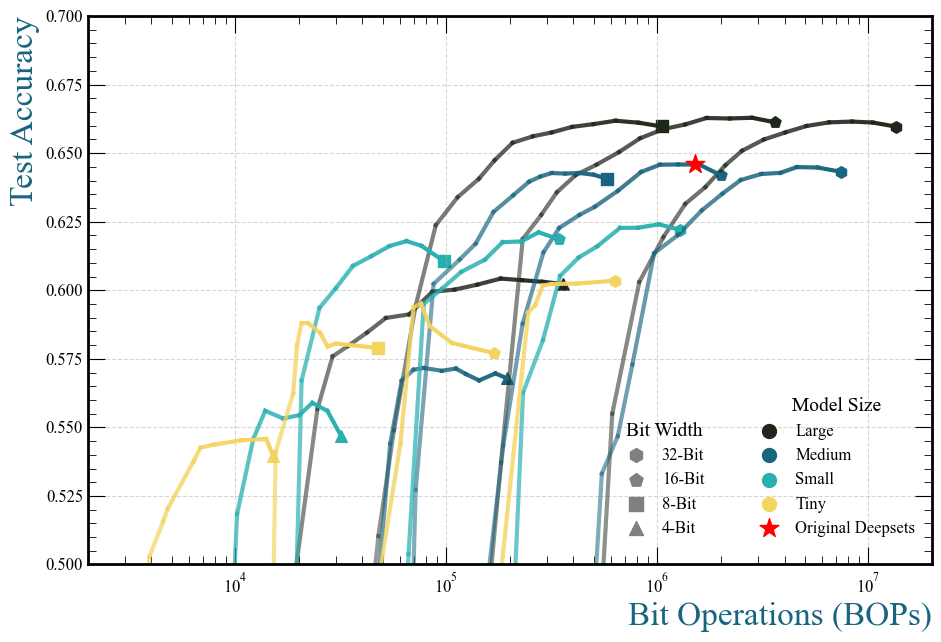

In [5]:
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import matplotlib.font_manager as font_manager
import mplhep as hep

# Add the custom font
font_path = '/Users/dimademler/Downloads/Times_New_Roman.ttf'
font_manager.fontManager.addfont(font_path)

# Set the default font to Times New Roman for all text elements
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

# Create a font dictionary
font = {'family': 'Times New Roman',
        'weight': 'normal'}

plt.style.use(hep.style.ROOT)

def plot_bops_vs_accuracy(data, output_folder='./plots'):
    plt.figure(figsize=(10, 7))
    
    model_order = ['Tiny', 'Small', 'Medium', 'Large']
    
    color_families = {
        'Tiny': '#F4D35E',
        'Small': '#28AFB0',
        'Medium': '#19647E',
        'Large': '#1F271B'
    }

    bit_width_shapes = {
        4: '^',  # triangle
        8: 's',  # square
        16: 'p',  # pentagon
        32: 'h'   # hexagon
    }

    # Create separate handles for legends
    color_handles = []
    shape_handles = []

    # Group data by model size and bit width
    grouped_data = defaultdict(lambda: defaultdict(list))

    for full_model_name, model_data in data.items():
        match = re.match(r"Deepsets (\w+) Model (\d+)-Bit QAT Model", full_model_name)
        if match:
            model_size, bit_width = match.groups()
            bit_width = int(bit_width)

            if model_size in model_order:
                for bops, accuracy, iteration in zip(model_data['total_bops'], model_data['test_accuracy'], model_data['iteration']):
                    grouped_data[model_size][bit_width].append((bops, accuracy, iteration))

    for model_size, bit_width_data in grouped_data.items():
        color = color_families[model_size]
        
        for bit_width, points in bit_width_data.items():
            shape = bit_width_shapes[bit_width]
            
            # Sort points by iteration
            sorted_points = sorted(points, key=lambda x: x[2])
            
            bops, accuracies, _ = zip(*sorted_points)
            
            iterations = [point[2] for point in sorted_points]
            max_iteration = max(iterations)
            for i in range(len(bops) - 1):
                start_opacity = 1 - 0.7 * (iterations[i] / max_iteration)
                end_opacity = 1 - 0.7 * (iterations[i+1] / max_iteration)
                plt.plot(bops[i:i+2], accuracies[i:i+2], color=color, 
                         alpha=(start_opacity + end_opacity) / 2, linewidth=3)
            
            # Plot scatter points for start and end
            plt.scatter(bops[0], accuracies[0], marker=shape, color=color, s=70)
            plt.scatter(bops[-1], accuracies[-1], marker=shape, color=color, s=70)

            # Add handles for legends (only once per model size and bit width)
            if model_size not in [h.get_label() for h in color_handles]:
                color_handles.append(plt.scatter([], [], color=color, s=100, label=model_size))
            if bit_width not in [int(h.get_label().split('-')[0]) for h in shape_handles]:
                shape_handles.append(plt.scatter([], [], marker=shape, color='gray', s=100, label=f'{bit_width}-Bit'))

    # Add the original Deepsets model point
    original_deepsets_bops = calculate_original_deepsets_bops(8)
    plt.scatter(original_deepsets_bops, 0.646, marker='*', color='red', s=200, zorder=5)
    color_handles.append(plt.scatter([], [], marker='*', color='red', s=200, label='Original Deepsets'))

    plt.tick_params(axis='y', labelsize=12) 
    plt.tick_params(axis='x', labelsize=12)

    plt.xscale('log') 
    plt.xlabel('Bit Operations (BOPs)', fontsize=24, **font, color='#19647E')
    plt.ylabel('Test Accuracy', fontsize=24, **font, color='#19647E')
    plt.grid(True, which="major", ls="--", alpha=0.5)
    plt.xlim(2e3, 2e7)
    plt.ylim(0.5, 0.7)

    # Increase tick label font size and ensure Times New Roman font
    plt.tick_params(axis='both', which='major', labelsize=12)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontname("Times New Roman")

    # Create two separate legends side by side with Times New Roman font
    first_legend = plt.legend(handles=color_handles, title='Model Size', loc='lower right', 
                              bbox_to_anchor=(1, 0.02), fontsize=12, title_fontsize=14)
    plt.setp(first_legend.get_title(), fontfamily='Times New Roman')
    for text in first_legend.get_texts():
        text.set_fontfamily('Times New Roman')
    plt.gca().add_artist(first_legend)  # Add the first legend to the plot

    second_legend = plt.legend(handles=shape_handles, title='Bit Width', loc='lower right', 
                               bbox_to_anchor=(0.75, 0.02), fontsize=12, title_fontsize=14)
    plt.setp(second_legend.get_title(), fontfamily='Times New Roman')
    for text in second_legend.get_texts():
        text.set_fontfamily('Times New Roman')

    plt.tight_layout()
    plt.savefig(f'{output_folder}/BOPs_vs_Accuracy_oct1_with_lines.pdf', dpi=300, bbox_inches='tight')
    print(f"Plot saved as {output_folder}/BOPs_vs_Accuracy_oct1_with_lines.pdf")
    
    plt.show()

extracted_data = extract_data(file_path)
plot_bops_vs_accuracy(extracted_data, '/Users/dimademler/Downloads')

Plot saved as /Users/dimademler/Downloads/BOPs_vs_Accuracy_oct6_Poster.pdf


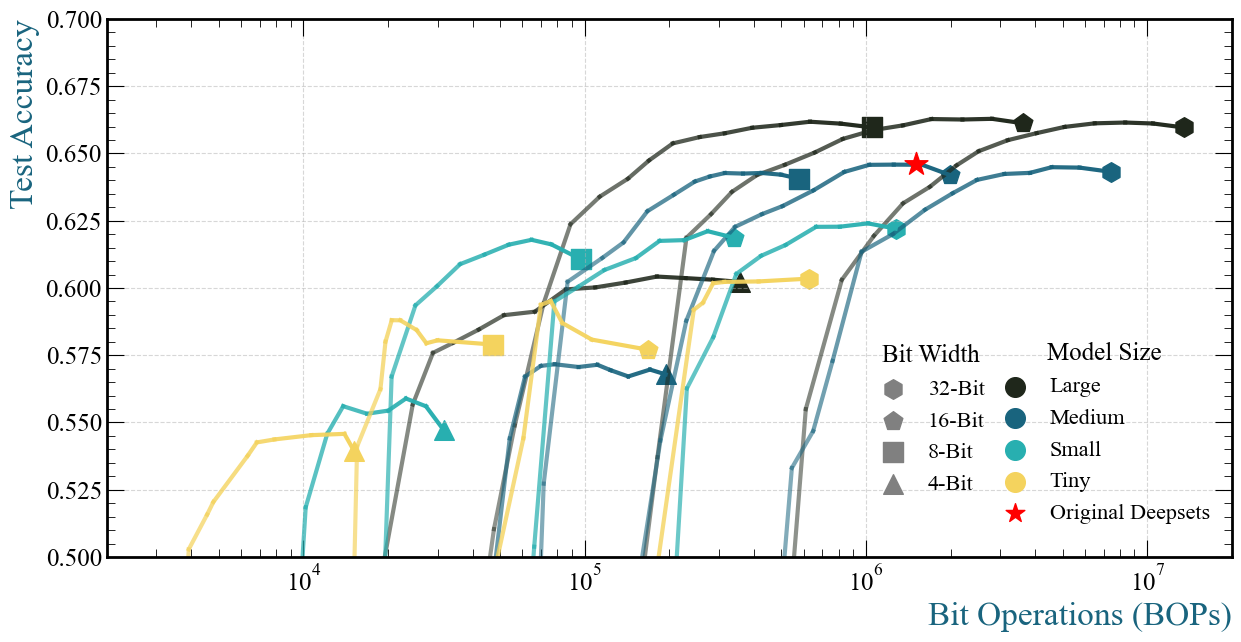

In [6]:
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import matplotlib.font_manager as font_manager
import mplhep as hep

# Add the custom font
font_path = '/Users/dimademler/Downloads/Times_New_Roman.ttf'
font_manager.fontManager.addfont(font_path)

# Set the default font to Times New Roman for all text elements
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

# Create a font dictionary
font = {'family': 'Times New Roman',
        'weight': 'normal'}

plt.style.use(hep.style.ROOT)

def plot_bops_vs_accuracy(data, output_folder='./plots'):
    plt.figure(figsize=(13, 7))
    
    model_order = ['Tiny', 'Small', 'Medium', 'Large']
    
    color_families = {
        'Tiny': '#F4D35E',
        'Small': '#28AFB0',
        'Medium': '#19647E',
        'Large': '#1F271B'
    }

    bit_width_shapes = {
        4: '^',  # triangle
        8: 's',  # square
        16: 'p',  # pentagon
        32: 'h'   # hexagon
    }

    # Create separate handles for legends
    color_handles = []
    shape_handles = []

    # Group data by model size and bit width
    grouped_data = defaultdict(lambda: defaultdict(list))

    for full_model_name, model_data in data.items():
        match = re.match(r"Deepsets (\w+) Model (\d+)-Bit QAT Model", full_model_name)
        if match:
            model_size, bit_width = match.groups()
            bit_width = int(bit_width)

            if model_size in model_order:
                for bops, accuracy, iteration in zip(model_data['total_bops'], model_data['test_accuracy'], model_data['iteration']):
                    grouped_data[model_size][bit_width].append((bops, accuracy, iteration))

    for model_size, bit_width_data in grouped_data.items():
        color = color_families[model_size]
        
        for bit_width, points in bit_width_data.items():
            shape = bit_width_shapes[bit_width]
            
            # Sort points by iteration
            sorted_points = sorted(points, key=lambda x: x[2])
            
            bops, accuracies, _ = zip(*sorted_points)
            
            iterations = [point[2] for point in sorted_points]
            max_iteration = max(iterations)
            for i in range(len(bops) - 1):
                start_opacity = 1 - 0.7 * (iterations[i] / max_iteration)
                end_opacity = 1 - 0.7 * (iterations[i+1] / max_iteration)
                plt.plot(bops[i:i+2], accuracies[i:i+2], color=color, 
                         alpha=(start_opacity + end_opacity) / 2, linewidth=3)
            
            # Plot scatter points for start and end
            plt.scatter(bops[0], accuracies[0], marker=shape, color=color, s=200)
            plt.scatter(bops[-1], accuracies[-1], marker=shape, color=color, s=70)

            # Add handles for legends (only once per model size and bit width)
            if model_size not in [h.get_label() for h in color_handles]:
                color_handles.append(plt.scatter([], [], color=color, s=200, label=model_size))
            if bit_width not in [int(h.get_label().split('-')[0]) for h in shape_handles]:
                shape_handles.append(plt.scatter([], [], marker=shape, color='gray', s=200, label=f'{bit_width}-Bit'))

    # Add the original Deepsets model point
    original_deepsets_bops = calculate_original_deepsets_bops(8)
    plt.scatter(original_deepsets_bops, 0.646, marker='*', color='red', s=300, zorder=5)
    color_handles.append(plt.scatter([], [], marker='*', color='red', s=200, label='Original Deepsets'))

    plt.tick_params(axis='y', labelsize=20) 
    plt.tick_params(axis='x', labelsize=20)

    plt.xscale('log') 
    plt.xlabel('Bit Operations (BOPs)', fontsize=24, **font, color='#19647E')
    plt.ylabel('Test Accuracy', fontsize=24, **font, color='#19647E')
    plt.grid(True, which="major", ls="--", alpha=0.5)
    plt.xlim(2e3, 2e7)
    plt.ylim(0.5, 0.7)

    # Increase tick label font size and ensure Times New Roman font
    plt.tick_params(axis='both', which='major', labelsize=18)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontname("Times New Roman")

    # Create two separate legends side by side with Times New Roman font
    first_legend = plt.legend(handles=color_handles, title='Model Size', loc='lower right', 
                              bbox_to_anchor=(1, 0.02), fontsize=16, title_fontsize=18)
    plt.setp(first_legend.get_title(), fontfamily='Times New Roman')
    for text in first_legend.get_texts():
        text.set_fontfamily('Times New Roman')
    plt.gca().add_artist(first_legend)  # Add the first legend to the plot

    second_legend = plt.legend(handles=shape_handles, title='Bit Width', loc='lower right', 
                               bbox_to_anchor=(0.8, 0.074), fontsize=16, title_fontsize=18)
    plt.setp(second_legend.get_title(), fontfamily='Times New Roman')
    for text in second_legend.get_texts():
        text.set_fontfamily('Times New Roman')

    plt.tight_layout()
    plt.savefig(f'{output_folder}/BOPs_vs_Accuracy_oct6_Poster.pdf', dpi=300, bbox_inches='tight')
    print(f"Plot saved as {output_folder}/BOPs_vs_Accuracy_oct6_Poster.pdf")
    
    plt.show()

extracted_data = extract_data(file_path)
plot_bops_vs_accuracy(extracted_data, '/Users/dimademler/Downloads')

Plot saved as /Users/dimademler/Downloads/BOPs_vs_Accuracy_oct15_Presentation.pdf


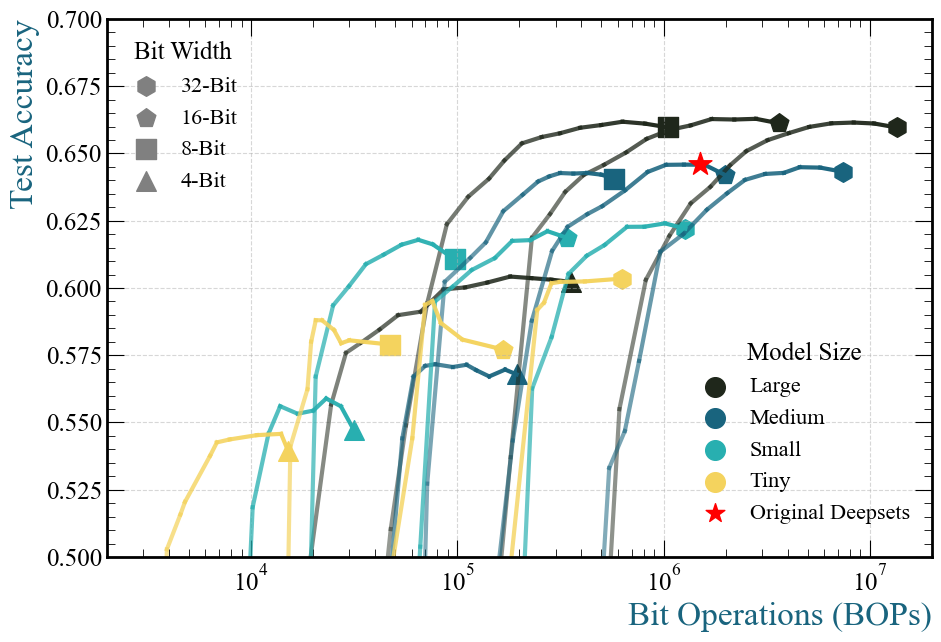

In [10]:
def plot_bops_vs_accuracy(data, output_folder='./plots'):
    plt.figure(figsize=(10, 7))
    
    model_order = ['Tiny', 'Small', 'Medium', 'Large']
    
    color_families = {
        'Tiny': '#F4D35E',
        'Small': '#28AFB0',
        'Medium': '#19647E',
        'Large': '#1F271B'
    }

    bit_width_shapes = {
        4: '^',  # triangle
        8: 's',  # square
        16: 'p',  # pentagon
        32: 'h'   # hexagon
    }

    # Create separate handles for legends
    color_handles = []
    shape_handles = []

    # Group data by model size and bit width
    grouped_data = defaultdict(lambda: defaultdict(list))

    for full_model_name, model_data in data.items():
        match = re.match(r"Deepsets (\w+) Model (\d+)-Bit QAT Model", full_model_name)
        if match:
            model_size, bit_width = match.groups()
            bit_width = int(bit_width)

            if model_size in model_order:
                for bops, accuracy, iteration in zip(model_data['total_bops'], model_data['test_accuracy'], model_data['iteration']):
                    grouped_data[model_size][bit_width].append((bops, accuracy, iteration))

    for model_size, bit_width_data in grouped_data.items():
        color = color_families[model_size]
        
        for bit_width, points in bit_width_data.items():
            shape = bit_width_shapes[bit_width]
            
            # Sort points by iteration
            sorted_points = sorted(points, key=lambda x: x[2])
            
            bops, accuracies, _ = zip(*sorted_points)
            
            iterations = [point[2] for point in sorted_points]
            max_iteration = max(iterations)
            for i in range(len(bops) - 1):
                start_opacity = 1 - 0.7 * (iterations[i] / max_iteration)
                end_opacity = 1 - 0.7 * (iterations[i+1] / max_iteration)
                plt.plot(bops[i:i+2], accuracies[i:i+2], color=color, 
                         alpha=(start_opacity + end_opacity) / 2, linewidth=3)
            
            # Plot scatter points for start and end
            plt.scatter(bops[0], accuracies[0], marker=shape, color=color, s=200)
            plt.scatter(bops[-1], accuracies[-1], marker=shape, color=color, s=70)

            # Add handles for legends (only once per model size and bit width)
            if model_size not in [h.get_label() for h in color_handles]:
                color_handles.append(plt.scatter([], [], color=color, s=200, label=model_size))
            if bit_width not in [int(h.get_label().split('-')[0]) for h in shape_handles]:
                shape_handles.append(plt.scatter([], [], marker=shape, color='gray', s=200, label=f'{bit_width}-Bit'))

    # Add the original Deepsets model point
    original_deepsets_bops = calculate_original_deepsets_bops(8)
    plt.scatter(original_deepsets_bops, 0.646, marker='*', color='red', s=300, zorder=5)
    color_handles.append(plt.scatter([], [], marker='*', color='red', s=200, label='Original Deepsets'))

    plt.tick_params(axis='y', labelsize=20) 
    plt.tick_params(axis='x', labelsize=20)

    plt.xscale('log') 
    plt.xlabel('Bit Operations (BOPs)', fontsize=24, **font, color='#19647E')
    plt.ylabel('Test Accuracy', fontsize=24, **font, color='#19647E')
    plt.grid(True, which="major", ls="--", alpha=0.5)
    plt.xlim(2e3, 2e7)
    plt.ylim(0.5, 0.7)

    # Increase tick label font size and ensure Times New Roman font
    plt.tick_params(axis='both', which='major', labelsize=18)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontname("Times New Roman")

    # Create two separate legends: one in the lower right, one in the upper left
    first_legend = plt.legend(handles=color_handles, title='Model Size', loc='lower right', 
                              bbox_to_anchor=(1, 0.02), fontsize=16, title_fontsize=18)
    plt.setp(first_legend.get_title(), fontfamily='Times New Roman')
    for text in first_legend.get_texts():
        text.set_fontfamily('Times New Roman')
    plt.gca().add_artist(first_legend)  # Add the first legend to the plot

    second_legend = plt.legend(handles=shape_handles, title='Bit Width', loc='upper left', 
                               bbox_to_anchor=(0, 1), fontsize=16, title_fontsize=18)
    plt.setp(second_legend.get_title(), fontfamily='Times New Roman')
    for text in second_legend.get_texts():
        text.set_fontfamily('Times New Roman')

    plt.tight_layout()
    plt.savefig(f'{output_folder}/BOPs_vs_Accuracy_oct15_Presentation.pdf', dpi=300, bbox_inches='tight')
    print(f"Plot saved as {output_folder}/BOPs_vs_Accuracy_oct15_Presentation.pdf")
    
    plt.show()
extracted_data = extract_data(file_path)
plot_bops_vs_accuracy(extracted_data, '/Users/dimademler/Downloads')

Plot saved as ./plots/BOPs_vs_Accuracy_sept23_with_lines_and_points.pdf


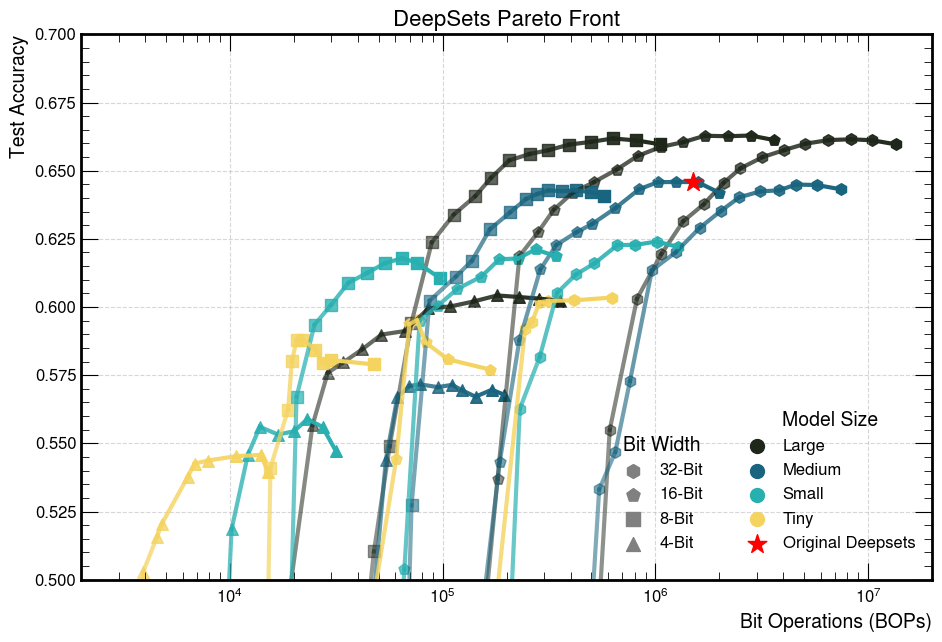

In [8]:
import matplotlib.pyplot as plt
import re
from collections import defaultdict

def plot_bops_vs_accuracy(data, output_folder='./plots'):
    plt.figure(figsize=(10, 7))
    
    model_order = ['Tiny', 'Small', 'Medium', 'Large']
    
    color_families = {
        'Tiny': '#F4D35E',
        'Small': '#28AFB0',
        'Medium': '#19647E',
        'Large': '#1F271B'
    }

    bit_width_shapes = {
        4: '^',  # triangle
        8: 's',  # square
        16: 'p',  # pentagon
        32: 'h'   # hexagon
    }

    # Create separate handles for legends
    color_handles = []
    shape_handles = []

    # Group data by model size and bit width
    grouped_data = defaultdict(lambda: defaultdict(list))

    for full_model_name, model_data in data.items():
        match = re.match(r"Deepsets (\w+) Model (\d+)-Bit QAT Model", full_model_name)
        if match:
            model_size, bit_width = match.groups()
            bit_width = int(bit_width)

            if model_size in model_order:
                for bops, accuracy, iteration in zip(model_data['total_bops'], model_data['test_accuracy'], model_data['iteration']):
                    grouped_data[model_size][bit_width].append((bops, accuracy, iteration))

    for model_size, bit_width_data in grouped_data.items():
        color = color_families[model_size]
        
        for bit_width, points in bit_width_data.items():
            shape = bit_width_shapes[bit_width]
            
            # Sort points by iteration
            sorted_points = sorted(points, key=lambda x: x[2])
            
            bops, accuracies, iterations = zip(*sorted_points)
            
            # Plot line connecting all points
            # plt.plot(bops, accuracies, color=color, alpha=0.5)

            iterations = [point[2] for point in sorted_points]
            max_iteration = max(iterations)
            for i in range(len(bops) - 1):
                start_opacity = 1 - 0.7 * (iterations[i] / max_iteration)
                end_opacity = 1 - 0.7 * (iterations[i+1] / max_iteration)
                plt.plot(bops[i:i+2], accuracies[i:i+2], color=color, 
                         alpha=(start_opacity + end_opacity) / 2, linewidth=3)
            
            # Plot all points
            max_iteration = max(iterations)
            for bop, accuracy, iteration in sorted_points:
                opacity = 1 - 0.7 * (iteration / max_iteration)  # This will range from 1 to 0.3
                plt.scatter(bop, accuracy, marker=shape, color=color, s=70, alpha=opacity)

            # Add handles for legends (only once per model size and bit width)
            if model_size not in [h.get_label() for h in color_handles]:
                color_handles.append(plt.scatter([], [], color=color, s=100, label=model_size))
            if bit_width not in [int(h.get_label().split('-')[0]) for h in shape_handles]:
                shape_handles.append(plt.scatter([], [], marker=shape, color='gray', s=100, label=f'{bit_width}-Bit'))

    # Add the original Deepsets model point
    original_deepsets_bops = calculate_original_deepsets_bops(8)
    plt.scatter(original_deepsets_bops, 0.646, marker='*', color='red', s=200, zorder=5)
    color_handles.append(plt.scatter([], [], marker='*', color='red', s=200, label='Original Deepsets'))

    plt.xscale('log') 
    plt.xlabel('Bit Operations (BOPs)', fontsize=14)
    plt.ylabel('Test Accuracy', fontsize=14)
    plt.title('DeepSets Pareto Front', fontsize=16)
    plt.grid(True, which="major", ls="--", alpha=0.5)
    plt.xlim(2e3, 2e7)
    plt.ylim(0.5, 0.7)

    # Increase tick label font size
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Create two separate legends side by side
    first_legend = plt.legend(handles=color_handles, title='Model Size', loc='lower right', 
                              bbox_to_anchor=(1, 0.02), fontsize=12, title_fontsize=14)
    plt.gca().add_artist(first_legend)  # Add the first legend to the plot
    plt.legend(handles=shape_handles, title='Bit Width', loc='lower right', 
               bbox_to_anchor=(0.75, 0.02), fontsize=12, title_fontsize=14)

    plt.tight_layout()
    plt.savefig(f'{output_folder}/BOPs_vs_Accuracy_sept23_with_lines_and_points.pdf', dpi=300, bbox_inches='tight')
    print(f"Plot saved as {output_folder}/BOPs_vs_Accuracy_sept23_with_lines_and_points.pdf")
    
    plt.show()

extracted_data = extract_data(file_path)
plot_bops_vs_accuracy(extracted_data)